# C2 Performance per Class

In [5]:
import os
import sys
sys.path.append('/zhome/d0/a/221493/thesis/code')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import gaussian_kde
from plot_config import PLOT_COLORS


# ── CONFIG ────────────────────────────────────────────────────────────────────
DISEASE   = 'effusion'
BASE_DIR  = '/zhome/d0/a/221493/thesis'
INPUT_DIR = f'{BASE_DIR}/results/C2_sim_cf/{DISEASE}'
OUTPUT_DIR = INPUT_DIR

disease_prob_col = f'{DISEASE}_prob'

cf_count = 1

In [6]:
# ── Load data and identify column groups ──────────────────────────────────────
valid_df = pd.read_csv(os.path.join(INPUT_DIR, f'valid_with_diff_vectors_{cf_count}.csv'))
train_df = pd.read_csv(os.path.join(INPUT_DIR, f'train_with_diff_vectors_{cf_count}.csv'))

diff_cols = [c for c in train_df.columns if c.startswith('delta_')]
emb_cols  = [c for c in train_df.columns if c.startswith('emb_')]
meta_cols = {disease_prob_col, f'{DISEASE}_pred', f'{DISEASE}_true',
             'correct', 'path', 'patient_id', 'cf_prob'}
attr_cols = [c for c in train_df.columns
             if c not in meta_cols
             and not c.startswith('delta_')
             and not c.startswith('emb_')]

print(f'Valid samples : {len(valid_df):,}')
print(f'Attr features : {len(attr_cols)}')
print(f'ΔA features   : {len(diff_cols)}')


Valid samples : 202
Attr features : 462
ΔA features   : 462


In [7]:
prob_va    = valid_df[[disease_prob_col]].values
diff_va    = valid_df[diff_cols].values
attr_va    = valid_df[attr_cols].values
cf_prob_va = valid_df[['cf_prob']].values

X_M6_va = np.hstack([prob_va, diff_va, attr_va, cf_prob_va])
print(f'M6 feature matrix shape: {X_M6_va.shape}  (expected 927)')

M6 feature matrix shape: (202, 926)  (expected 927)


In [8]:
# ── Load models and their saved scalers ───────────────────────────────────────
lr_m6        = joblib.load(f'{INPUT_DIR}/cf{cf_count}_lr/lr_m6_model.pkl')
lr_m6_scaler = joblib.load(f'{INPUT_DIR}/cf{cf_count}_lr/lr_m6_scaler.pkl')

mlp_m6        = joblib.load(f'{INPUT_DIR}/cf{cf_count}_mlp/mlp_m6_model.pkl')
mlp_m6_scaler = joblib.load(f'{INPUT_DIR}/cf{cf_count}_mlp/mlp_m6_scaler.pkl')

rf_m6 = joblib.load(f'{INPUT_DIR}/cf{cf_count}_rf/rf_m6_model.pkl')


In [9]:
# ── Run inference ─────────────────────────────────────────────────────────────
lr_probs  = lr_m6.predict_proba(lr_m6_scaler.transform(X_M6_va))[:, 1]
mlp_probs = mlp_m6.predict_proba(mlp_m6_scaler.transform(X_M6_va.astype(np.float32)))[:, 1]
rf_probs  = rf_m6.predict_proba(X_M6_va)[:, 1]

print(f'LR  M6 probs: min={lr_probs.min():.4f}, max={lr_probs.max():.4f}, mean={lr_probs.mean():.4f}')
print(f'MLP M6 probs: min={mlp_probs.min():.4f}, max={mlp_probs.max():.4f}, mean={mlp_probs.mean():.4f}')
print(f'RF  M6 probs: min={rf_probs.min():.4f}, max={rf_probs.max():.4f}, mean={rf_probs.mean():.4f}')

LR  M6 probs: min=0.0193, max=0.9950, mean=0.5473
MLP M6 probs: min=0.0020, max=1.0000, mean=0.7683
RF  M6 probs: min=0.2650, max=1.0000, mean=0.7694


In [10]:
# ── Masks conditioned on ground truth ─────────────────────────────────────────
true_label = valid_df[f'{DISEASE}_true'].values
correct    = valid_df['correct'].values

tp_mask = (true_label == 1) & (correct == 1)   # correct = true positive
fn_mask = (true_label == 1) & (correct == 0)   # incorrect = false negative
tn_mask = (true_label == 0) & (correct == 1)   # correct = true negative
fp_mask = (true_label == 0) & (correct == 0)   # incorrect = false positive

print(f'Disease present — TP: {tp_mask.sum()}  FN: {fn_mask.sum()}')
print(f'Disease absent  — TN: {tn_mask.sum()}  FP: {fp_mask.sum()}')

Disease present — TP: 90  FN: 27
Disease absent  — TN: 65  FP: 20


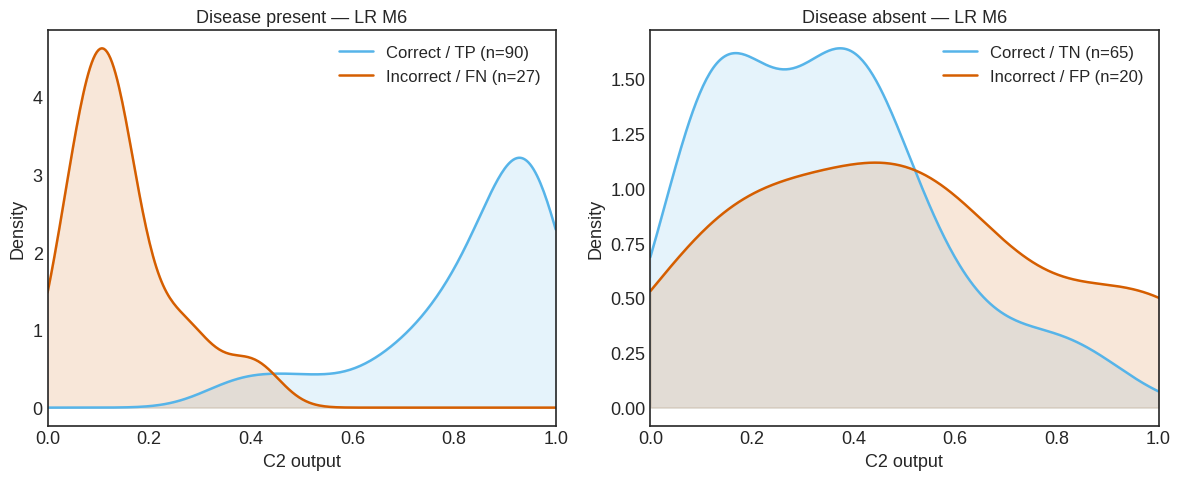

Saved → /zhome/d0/a/221493/thesis/results/C2_sim_cf/effusion/distributions/distribution_lr_m6.png


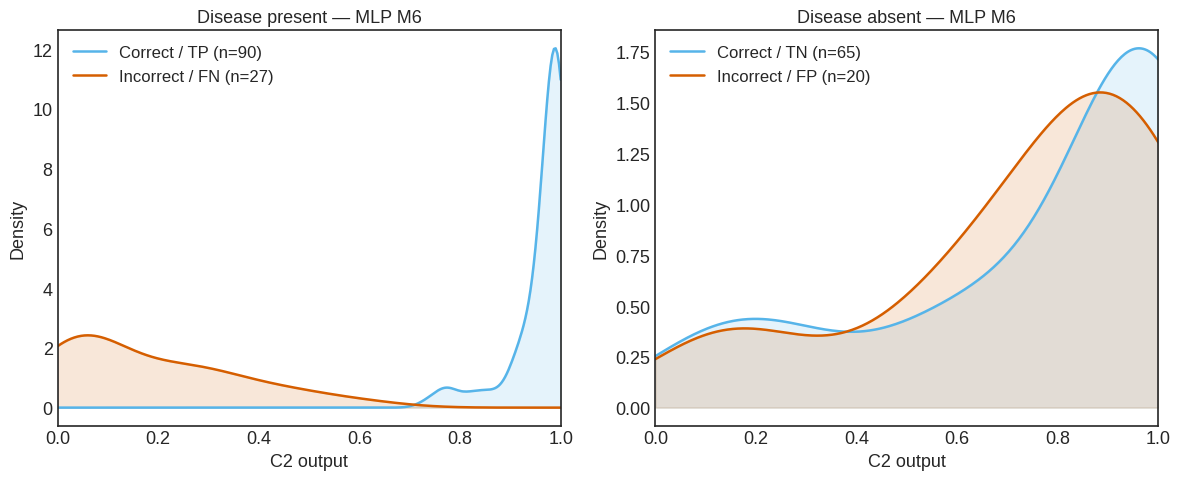

Saved → /zhome/d0/a/221493/thesis/results/C2_sim_cf/effusion/distributions/distribution_mlp_m6.png


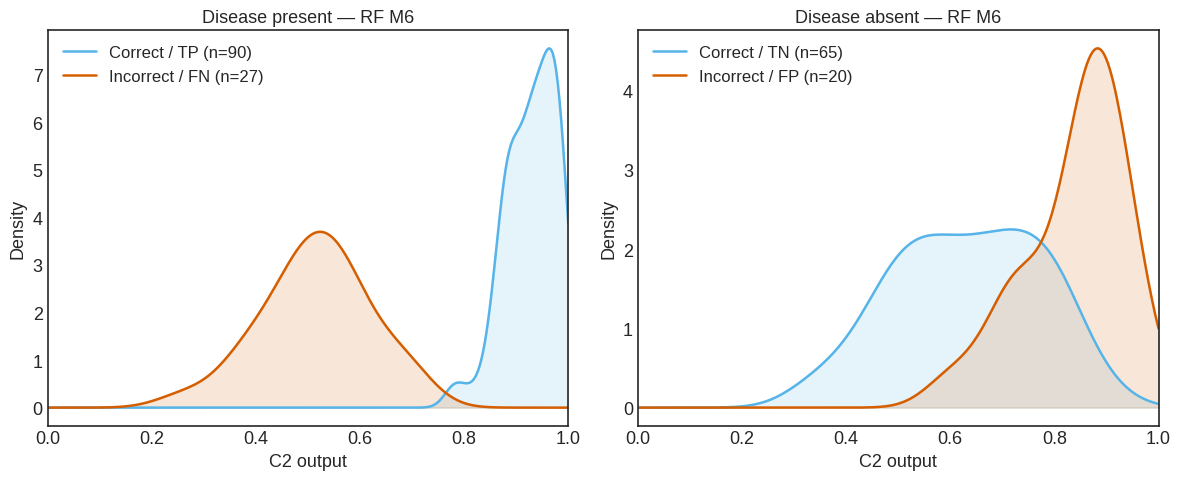

Saved → /zhome/d0/a/221493/thesis/results/C2_sim_cf/effusion/distributions/distribution_rf_m6.png


In [11]:
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'font.family':    'sans-serif',
    'font.size':      13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize':13,
    'ytick.labelsize':13,
    'legend.fontsize':12,
    'axes.linewidth': 1.2,
})

x_grid = np.linspace(0, 1, 300)
COLOR_CORRECT   = PLOT_COLORS['M1']
COLOR_INCORRECT = PLOT_COLORS['B5']

os.makedirs(f'{OUTPUT_DIR}/distributions', exist_ok=True)

def kde_curve(probs, mask, x_grid, min_samples=5):
    vals = probs[mask]
    if len(vals) < min_samples:
        return np.zeros_like(x_grid)
    if np.std(vals) < 1e-6:
        return np.zeros_like(x_grid)
    return gaussian_kde(vals, bw_method='scott')(x_grid)

for model_name, c2_probs in [('LR', lr_probs), ('MLP', mlp_probs), ('RF', rf_probs)]:

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    ax = axes[0]
    tp_kde = kde_curve(c2_probs, tp_mask, x_grid)
    fn_kde = kde_curve(c2_probs, fn_mask, x_grid)
    ax.plot(x_grid, tp_kde, color=COLOR_CORRECT,   lw=1.8, label=f'Correct / TP (n={tp_mask.sum()})')
    ax.fill_between(x_grid, tp_kde, alpha=0.15, color=COLOR_CORRECT)
    ax.plot(x_grid, fn_kde, color=COLOR_INCORRECT, lw=1.8, label=f'Incorrect / FN (n={fn_mask.sum()})')
    ax.fill_between(x_grid, fn_kde, alpha=0.15, color=COLOR_INCORRECT)
    ax.set_xlabel('C2 output')
    ax.set_ylabel('Density')
    ax.set_title(f'Disease present — {model_name} M6')
    ax.set_xlim(0, 1)
    ax.legend()

    ax = axes[1]
    tn_kde = kde_curve(c2_probs, tn_mask, x_grid)
    fp_kde = kde_curve(c2_probs, fp_mask, x_grid)
    ax.plot(x_grid, tn_kde, color=COLOR_CORRECT,   lw=1.8, label=f'Correct / TN (n={tn_mask.sum()})')
    ax.fill_between(x_grid, tn_kde, alpha=0.15, color=COLOR_CORRECT)
    ax.plot(x_grid, fp_kde, color=COLOR_INCORRECT, lw=1.8, label=f'Incorrect / FP (n={fp_mask.sum()})')
    ax.fill_between(x_grid, fp_kde, alpha=0.15, color=COLOR_INCORRECT)
    ax.set_xlabel('C2 output')
    ax.set_ylabel('Density')
    ax.set_title(f'Disease absent — {model_name} M6')
    ax.set_xlim(0, 1)
    ax.legend()

    plt.tight_layout()
    save_path = f'{OUTPUT_DIR}/distributions/distribution_{model_name.lower()}_m6.png'
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')

---

# ROC Curves for C2 Models

In [12]:
import json
import matplotlib.pyplot as plt
import scienceplots
import os

In [13]:
# Load the json with the ROC Curve data

BASE_DIR = '/zhome/d0/a/221493/thesis/'
ROC_PATH = BASE_DIR + f"results/C2_sim_cf/effusion/roc_data_{cf_count}.json"
OUTPUT_DIR = BASE_DIR + f"results/C2_sim_cf/effusion/rocs"

In [25]:
# Which models to plot — one figure per model
MODELS_TO_PLOT = ['LR', 'RF', 'MLP']

# Which configs to show per model — comment out any you don't want
CONFIGS_TO_SHOW = {
    'LR':  ['B1', 'B2', 'B4', 'M3', 'M6'],
    'RF':  ['B1', 'B2', 'B4', 'M3', 'M6'],
    'MLP': ['B1', 'B2', 'B4', 'M3', 'M6'],
}

# Colors and styles — edit freely
COLORS = {
    'B1': '#999999',
    'B2': '#CC79A7',
    'B3': '#F0E442',
    'B4': '#E69F00',
    'B5': '#D55E00',
    'M1': '#56B4E9',
    'M2': '#0072B2',
    'M3': '#009E73',
    'M4': '#9370DB',
    'M5': '#2D2D2D',
    'M6': '#CC0000',
}
LINESTYLES = {k: '--' if k.startswith('B') else '-' for k in COLORS}
LINEWIDTHS = {k:  2 if k.startswith('B') else 3  for k in COLORS}

LABELS = {
    'B1': 'B1 (Prob only)',
    'B2': 'B2 (Attrs only)',
    'B3': 'B3 (Embeddings only)',
    'B4': 'B4 (Prob+Attrs)',
    'B5': 'B5 (Prob+Emb)',
    'M1': 'M1 (ΔA only)',
    'M2': 'M2 (Prob+ΔA)',
    'M3': 'M3 (Prob+ΔA+Attrs)',
    'M4': 'M4 (Prob+ΔA+Emb)',
    'M5': 'M5 (Prob+ΔA+Attrs+Emb)',
    'M6': 'M6 (Prob+ΔA+Attrs+CFProb)',
}

# ── Load ROC data ─────────────────────────────────────────────────────────────
with open(ROC_PATH) as f:
    roc_data = json.load(f)


In [26]:
roc_data

{'LR': {'B1': {'fpr': [0.0,
    0.0,
    0.0,
    0.02127659574468085,
    0.02127659574468085,
    0.0425531914893617,
    0.0425531914893617,
    0.06382978723404255,
    0.06382978723404255,
    0.0851063829787234,
    0.0851063829787234,
    0.14893617021276595,
    0.14893617021276595,
    0.1702127659574468,
    0.1702127659574468,
    0.23404255319148937,
    0.23404255319148937,
    0.2553191489361702,
    0.2553191489361702,
    0.2978723404255319,
    0.2978723404255319,
    0.3404255319148936,
    0.3404255319148936,
    0.3617021276595745,
    0.3617021276595745,
    0.3829787234042553,
    0.3829787234042553,
    0.40425531914893614,
    0.40425531914893614,
    0.425531914893617,
    0.425531914893617,
    0.46808510638297873,
    0.46808510638297873,
    0.48936170212765956,
    0.48936170212765956,
    0.5531914893617021,
    0.5531914893617021,
    0.6595744680851063,
    0.6595744680851063,
    0.723404255319149,
    0.723404255319149,
    0.7446808510638298,
    0.74

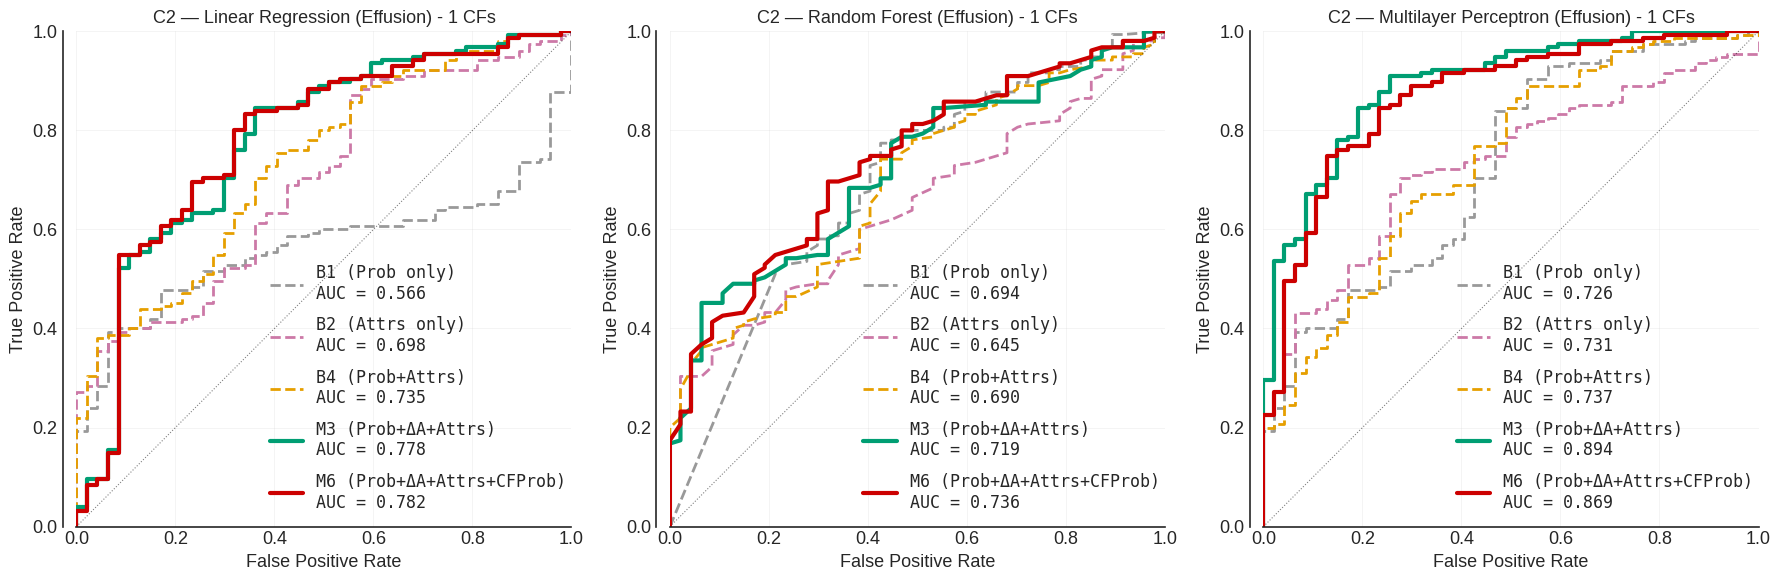

Saved → /zhome/d0/a/221493/thesis/results/C2_sim_cf/effusion/rocs/roc_all_models_1.png


In [27]:
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         13,
    'axes.titlesize':    13,
    'axes.labelsize':    13,
    'xtick.labelsize':   13,
    'ytick.labelsize':   13,
    'legend.fontsize':   11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.2,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.6,
    'lines.linewidth':   1.8,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, model_name in zip(axes, MODELS_TO_PLOT):
    for tag in CONFIGS_TO_SHOW[model_name]:
        d   = roc_data[model_name][tag]
        auc = d['auc']
        # two-line label: config name on first line, AUC on second
        ax.plot(d['fpr'], d['tpr'],
                color=COLORS[tag],
                lw=LINEWIDTHS[tag],
                ls=LINESTYLES[tag],
                label=f"{LABELS[tag]}\nAUC = {auc:.3f}")

    ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    name = "Linear Regression" if model_name == 'LR' else ("Random Forest" if model_name == 'RF' else "Multilayer Perceptron")
    ax.set_title(f'C2 — {name} (Effusion) - {cf_count} CFs')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.spines['left'].set_position(('outward', 10))
    ax.legend(loc='lower right',
              bbox_to_anchor=(1.02, 0.0),
              prop={'family': 'monospace', 'size': 12},
              framealpha=0.95,
              edgecolor='#cccccc',
              handlelength=2,
              labelspacing=0.8)
    ax.grid(alpha=0.30, linewidth=0.5)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, f'roc_all_models_{cf_count}.png')
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(out_path, dpi=600, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

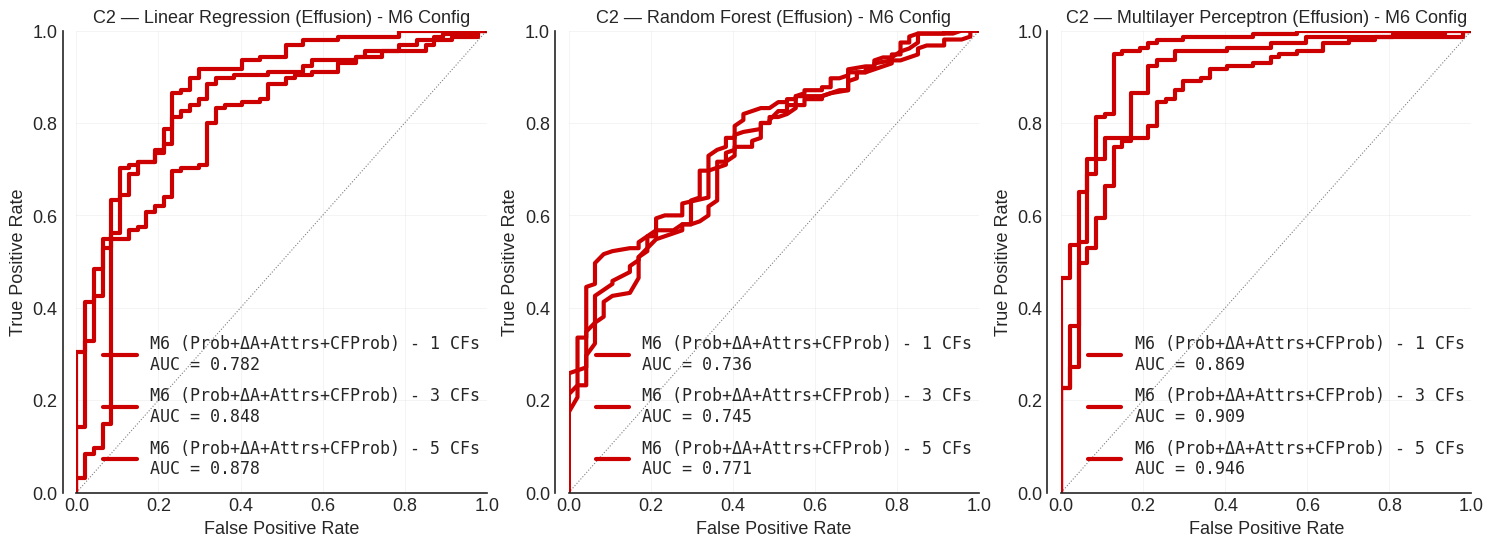

In [ ]:
# Figure with 3 ROC plots (one for each model - lr, rf, mlp)
# Each plot shows the ROC Curve of M6 for 1cf, 3 cf and 5 cf

roc_data_1 = roc_data  # from cf_count = 1
roc_data_3 = json.load(open(BASE_DIR + f"results/C2_sim_cf/effusion/roc_data_3.json"))
roc_data_5 = json.load(open(BASE_DIR +  f"results/C2_sim_cf/effusion/roc_data_5.json"))

colors_cf = {
    1: "#6C01D7",  # Red for 1 CF
    3: '#0072B2',  # Blue for 3 CFs
    5: '#009E73',  # Green for 5 CFs}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, model_name in zip(axes, MODELS_TO_PLOT):
    for roc_data, cf in zip([roc_data_1, roc_data_3, roc_data_5], [1, 3, 5]):
        d = roc_data[model_name]['M6']
        ax.plot(d['fpr'], d['tpr'],
                # Colours cant be M6 becasye they need to differ by CF count, so we use new colors that are similar but differ by shade
                color=colors_cf[cf],
                lw=LINEWIDTHS['M6'],
                ls=LINESTYLES['M6'],
                label=f"{LABELS['M6']} - {cf} CFs\nAUC = {d['auc']:.3f}")   
    ax.plot([0, 1], [0, 1], 'k:', lw=0.8, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    name = "Linear Regression" if model_name == 'LR' else ("Random Forest" if model_name == 'RF' else "Multilayer Perceptron")
    ax.set_title(f'C2 — {name} (Effusion) - M6 Config')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.spines['left'].set_position(('outward', 10))
    ax.legend(loc='lower right',
              bbox_to_anchor=(1.02, 0.0),
              prop={'family': 'monospace', 'size': 12},
              framealpha=0.95,
              edgecolor='#cccccc',
              handlelength=2,
              labelspacing=0.8)
    ax.grid(alpha=0.30, linewidth=0.5)



# Translation into clinical implications
1 - Pick a model and a threshold

2 - Use it to predict the correctness of C0 decisions

3 - Reject C0 decisions predicted to be incorrect, and accept those predicted to be correct

4 - This will reduce the number of incorrect C0 decisions, but also reduce the number of correct C0 decisions (since some will be rejected by mistake)

5 - Calculate the trade off "Decreasing FPR from 25% to 10%, means rejecting 15% of incorrect C0 decisions, but also rejecting 10% of correct C0 decisions"

In [17]:
import numpy as np
import pandas as pd

# ── Config ────────────────────────────────────────────────────────────────────
THRESHOLDS = np.arange(0.1, 1.0, 0.1)  # operating points to evaluate


In [18]:
# ── Load C2 scores ────────────────────────────────────────────────────────────
df = valid_df.copy()
df['c2_prob'] = mlp_probs  # or lr_probs / rf_probs

correct   = df['correct'].values
c2_scores = df['c2_prob'].values

n_total     = len(df)
n_incorrect = (correct == 0).sum()
n_correct   = (correct == 1).sum()

In [19]:
# ── Evaluate each threshold ───────────────────────────────────────────────────
rows = []
for thresh in THRESHOLDS:
    # C2 flags samples BELOW threshold as likely incorrect
    flagged = c2_scores < thresh

    incorrect_caught   = ((correct == 0) & flagged).sum()   # C0 errors caught
    correct_flagged    = ((correct == 1) & flagged).sum()   # C0 correct but wrongly flagged
    incorrect_missed   = ((correct == 0) & ~flagged).sum()  # C0 errors missed

    rows.append({
        'threshold':           round(thresh, 2),
        'flagged_total':       flagged.sum(),
        'flagged_pct':         flagged.mean() * 100,
        'incorrect_caught':    incorrect_caught,
        'incorrect_caught_pct': incorrect_caught / n_incorrect * 100,
        'correct_flagged':     correct_flagged,
        'correct_flagged_pct': correct_flagged / n_correct * 100,
        'incorrect_missed':    incorrect_missed,
        'incorrect_missed_pct': incorrect_missed / n_incorrect * 100,
    })

results = pd.DataFrame(rows)
results

,threshold,flagged_total,flagged_pct,incorrect_caught,incorrect_caught_pct,correct_flagged,correct_flagged_pct,incorrect_missed,incorrect_missed_pct
0,0.1,17,8.415842,14,29.787234,3,1.935484,33,70.212766
1,0.2,24,11.881188,17,36.170213,7,4.516129,30,63.829787
2,0.3,34,16.831683,23,48.936170,11,7.096774,24,51.063830
3,0.4,39,19.306931,27,57.446809,12,7.741935,20,42.553191
4,0.5,42,20.792079,29,61.702128,13,8.387097,18,38.297872
5,0.6,48,23.762376,31,65.957447,17,10.967742,16,34.042553
6,0.7,53,26.237624,33,70.212766,20,12.903226,14,29.787234
7,0.8,66,32.673267,36,76.595745,30,19.354839,11,23.404255
8,0.9,79,39.108911,40,85.106383,39,25.161290,7,14.893617


In [20]:
# Evaluate the accuracy of C0
# Load C0s predictions
c0_preds = valid_df[f'{DISEASE}_pred'].values
c0_true  = valid_df[f'{DISEASE}_true'].values

# Calculate accuracy
c0_correct = (c0_preds == c0_true).sum()
c0_total   = len(c0_preds)
c0_accuracy = c0_correct / c0_total * 100
print(f"C0 Accuracy: {c0_accuracy:.2f}% ({c0_correct}/{c0_total})")

C0 Accuracy: 76.73% (155/202)


> at threshold 0.5, C2 flags 20% of all cases as "WRONG", catching 60% of C0's mistakes while wrongly flagging only 8% of its correct predictions

In [21]:
print("Original C0 accuracy: {:.2f}% ({}/{})".format(c0_accuracy, c0_correct, c0_total))

rows = []
for thresh in THRESHOLDS:
    flagged   = c2_scores < thresh
    accepted  = ~flagged  # cases C2 trusts

    accepted_correct = ((c0_preds == c0_true) & accepted).sum()
    accepted_total   = accepted.sum()
    accepted_accuracy = accepted_correct / accepted_total * 100 if accepted_total > 0 else 0

    print(f"At threshold {thresh:.2f} | "
          f"C2 rejects {flagged.sum()} cases ({flagged.mean()*100:.1f}%) | "
          f"remaining {accepted_total} cases | "
          f"C0 accuracy on accepted: {accepted_accuracy:.2f}%")

    rows.append({
        'threshold':         round(thresh, 2),
        'rejected':          flagged.sum(),
        'rejected_pct':      flagged.mean() * 100,
        'accepted':          accepted_total,
        'accepted_accuracy': accepted_accuracy,
    })

rejection_results = pd.DataFrame(rows)
rejection_results

Original C0 accuracy: 76.73% (155/202)
At threshold 0.10 | C2 rejects 17 cases (8.4%) | remaining 185 cases | C0 accuracy on accepted: 82.16%
At threshold 0.20 | C2 rejects 24 cases (11.9%) | remaining 178 cases | C0 accuracy on accepted: 83.15%
At threshold 0.30 | C2 rejects 34 cases (16.8%) | remaining 168 cases | C0 accuracy on accepted: 85.71%
At threshold 0.40 | C2 rejects 39 cases (19.3%) | remaining 163 cases | C0 accuracy on accepted: 87.73%
At threshold 0.50 | C2 rejects 42 cases (20.8%) | remaining 160 cases | C0 accuracy on accepted: 88.75%
At threshold 0.60 | C2 rejects 48 cases (23.8%) | remaining 154 cases | C0 accuracy on accepted: 89.61%
At threshold 0.70 | C2 rejects 53 cases (26.2%) | remaining 149 cases | C0 accuracy on accepted: 90.60%
At threshold 0.80 | C2 rejects 66 cases (32.7%) | remaining 136 cases | C0 accuracy on accepted: 91.91%
At threshold 0.90 | C2 rejects 79 cases (39.1%) | remaining 123 cases | C0 accuracy on accepted: 94.31%


,threshold,rejected,rejected_pct,accepted,accepted_accuracy
0,0.1,17,8.415842,185,82.162162
1,0.2,24,11.881188,178,83.146067
2,0.3,34,16.831683,168,85.714286
3,0.4,39,19.306931,163,87.730061
4,0.5,42,20.792079,160,88.750000
5,0.6,48,23.762376,154,89.610390
6,0.7,53,26.237624,149,90.604027
7,0.8,66,32.673267,136,91.911765
8,0.9,79,39.108911,123,94.308943


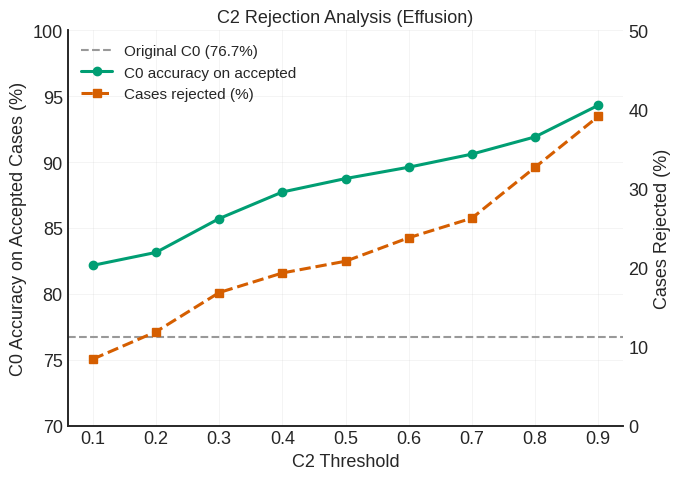

In [22]:
fig, ax1 = plt.subplots(figsize=(7, 5))

ax2 = ax1.twinx()

# Left axis — accuracy on accepted cases
ax1.axhline(c0_accuracy, color='#999999', lw=1.5, ls='--', label=f'Original C0 ({c0_accuracy:.1f}%)')
ax1.plot(rejection_results['threshold'], rejection_results['accepted_accuracy'],
         color=COLORS['M3'], lw=2.2, marker='o', markersize=6, label='C0 accuracy on accepted')
ax1.set_xlabel('C2 Threshold')
ax1.set_ylabel('C0 Accuracy on Accepted Cases (%)')
ax1.set_ylim(70, 100)

# Right axis — % of cases rejected
ax2.plot(rejection_results['threshold'], rejection_results['rejected_pct'],
         color=COLORS['B5'], lw=2.2, marker='s', markersize=6, ls='--', label='Cases rejected (%)')
ax2.set_ylabel('Cases Rejected (%)')
ax2.set_ylim(0, 50)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title('C2 Rejection Analysis (Effusion)')
ax1.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'c2_rejection_analysis_{cf_count}.png'), dpi=600, bbox_inches='tight')
plt.show()

In [23]:
print("Original C0 FPR: {:.2f}% | FNR: {:.2f}%".format(
    ((c0_preds == 1) & (c0_true == 0)).sum() / (c0_true == 0).sum() * 100,
    ((c0_preds == 0) & (c0_true == 1)).sum() / (c0_true == 1).sum() * 100,
))
for thresh in THRESHOLDS:
    flagged  = c2_scores < thresh
    accepted = ~flagged

    # On accepted cases only
    tn = ((c0_preds == 0) & (c0_true == 0) & accepted).sum()
    fp = ((c0_preds == 1) & (c0_true == 0) & accepted).sum()
    fn = ((c0_preds == 0) & (c0_true == 1) & accepted).sum()
    tp = ((c0_preds == 1) & (c0_true == 1) & accepted).sum()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    print(f"Threshold {thresh:.2f} | Rejected {flagged.mean()*100:.1f}% | FPR {fpr:.3f} | FNR {fnr:.3f}")

Original C0 FPR: 23.53% | FNR: 23.08%
Threshold 0.10 | Rejected 8.4% | FPR 0.244 | FNR 0.126
Threshold 0.20 | Rejected 11.9% | FPR 0.237 | FNR 0.118
Threshold 0.30 | Rejected 16.8% | FPR 0.239 | FNR 0.072
Threshold 0.40 | Rejected 19.3% | FPR 0.243 | FNR 0.032
Threshold 0.50 | Rejected 20.8% | FPR 0.246 | FNR 0.011
Threshold 0.60 | Rejected 23.8% | FPR 0.238 | FNR 0.011
Threshold 0.70 | Rejected 26.2% | FPR 0.237 | FNR 0.000
Threshold 0.80 | Rejected 32.7% | FPR 0.220 | FNR 0.000
Threshold 0.90 | Rejected 39.1% | FPR 0.167 | FNR 0.000


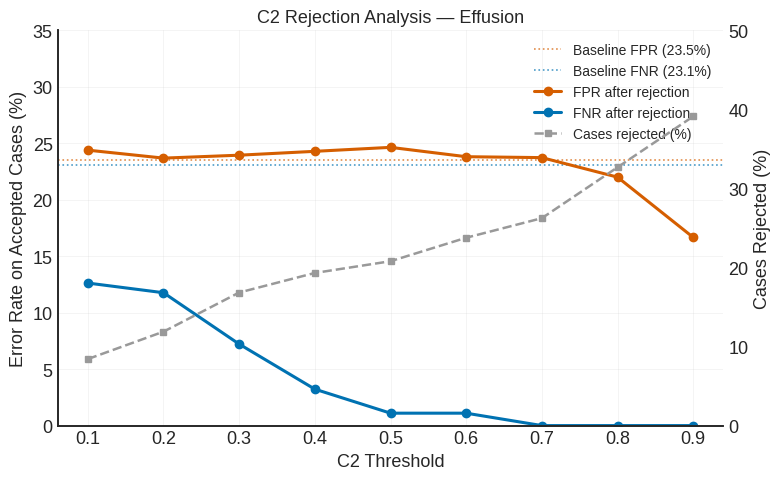

In [24]:
rows = []
for thresh in THRESHOLDS:
    flagged  = c2_scores < thresh
    accepted = ~flagged

    tp = ((c0_preds == 1) & (c0_true == 1) & accepted).sum()
    fp = ((c0_preds == 1) & (c0_true == 0) & accepted).sum()
    tn = ((c0_preds == 0) & (c0_true == 0) & accepted).sum()
    fn = ((c0_preds == 0) & (c0_true == 1) & accepted).sum()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    rows.append({
        'threshold':    round(thresh, 2),
        'rejected_pct': flagged.mean() * 100,
        'fpr':          fpr * 100,
        'fnr':          fnr * 100,
    })

clinical = pd.DataFrame(rows)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

fp_total = ((c0_preds == 1) & (c0_true == 0)).sum()
tn_total = ((c0_preds == 0) & (c0_true == 0)).sum()
fn_total = ((c0_preds == 0) & (c0_true == 1)).sum()
tp_total = ((c0_preds == 1) & (c0_true == 1)).sum()

# Baseline reference lines
ax1.axhline(fp_total / (fp_total + tn_total) * 100, color=COLORS['B5'],
            lw=1.2, ls=':', alpha=0.7, label=f'Baseline FPR ({fp_total / (fp_total + tn_total)*100:.1f}%)')
ax1.axhline(fn_total / (fn_total + tp_total) * 100, color=COLORS['M2'],
            lw=1.2, ls=':', alpha=0.7, label=f'Baseline FNR ({fn_total / (fn_total + tp_total)*100:.1f}%)')

# FPR and FNR after rejection
ax1.plot(clinical['threshold'], clinical['fpr'],
         color=COLORS['B5'], lw=2.2, marker='o', markersize=6, label='FPR after rejection')
ax1.plot(clinical['threshold'], clinical['fnr'],
         color=COLORS['M2'], lw=2.2, marker='o', markersize=6, label='FNR after rejection')

# Rejected cases on right axis
ax2.plot(clinical['threshold'], clinical['rejected_pct'],
         color='#999999', lw=1.8, marker='s', markersize=5, ls='--', label='Cases rejected (%)')

ax1.set_xlabel('C2 Threshold')
ax1.set_ylabel('Error Rate on Accepted Cases (%)')
ax2.set_ylabel('Cases Rejected (%)')
ax1.set_ylim(0, 35)
ax2.set_ylim(0, 50)
ax1.set_title('C2 Rejection Analysis — Effusion')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

ax1.grid(alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'c2_clinical_rejection_{cf_count}.png'), dpi=600, bbox_inches='tight')
plt.show()